# 数据可视化：每个家族 5 个训练样本 + 5 个 test 样本

**目标**：直观认识 10 个家族的数据形态差异，以及 test 集的地震形态。

**每样本展示**：
- **速度图**（70×70，jet 色标，速度范围 1500–4500 m/s）
- **5 个源的地震道**（`log1p(abs)`，时间×检波器，灰度）

**内容**：
1. 每个家族取 5 个分布样本（sample 0/100/200/300/400）→ 10 张图（每张 5 行 × 6 列：1 速度 + 5 源）
2. test 前 5 个文件 → 1 张图（5 行 × 5 列：5 源，无速度真值）


In [1]:
# 1. 环境 + 导入 + 数据加载辅助
import os
import glob
from pathlib import Path

import numpy as np
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt

from config import Cfg
from data import find_pairs

# 训练配对文件（按 Cfg.families 顺序；每家族 2 文件 × 500 样本）
pairs = find_pairs(Cfg.train_data_dir, Cfg.families)
per_family = len(pairs) // len(Cfg.families)
print(f"配对文件 {len(pairs)}，每家族 {per_family} 文件 × 500 样本")


def load_train_sample(family_idx, sample_id):
    """加载某家族第 sample_id 个样本（自动跨文件）。返回 (seis, vel)。"""
    file_in_family = (sample_id // 500) % per_family
    within = sample_id % 500
    s_path, v_path = pairs[family_idx * per_family + file_in_family]
    seis = np.array(np.load(s_path, mmap_mode="r")[within], dtype=np.float32)   # (5,1000,70)
    vel = np.array(np.load(v_path, mmap_mode="r")[within], dtype=np.float32)    # (1,70,70)
    vel = vel.squeeze(0) if vel.ndim == 3 else vel                              # (70,70)
    return seis, vel


[info] total paired files: 20
配对文件 20，每家族 2 文件 × 500 样本


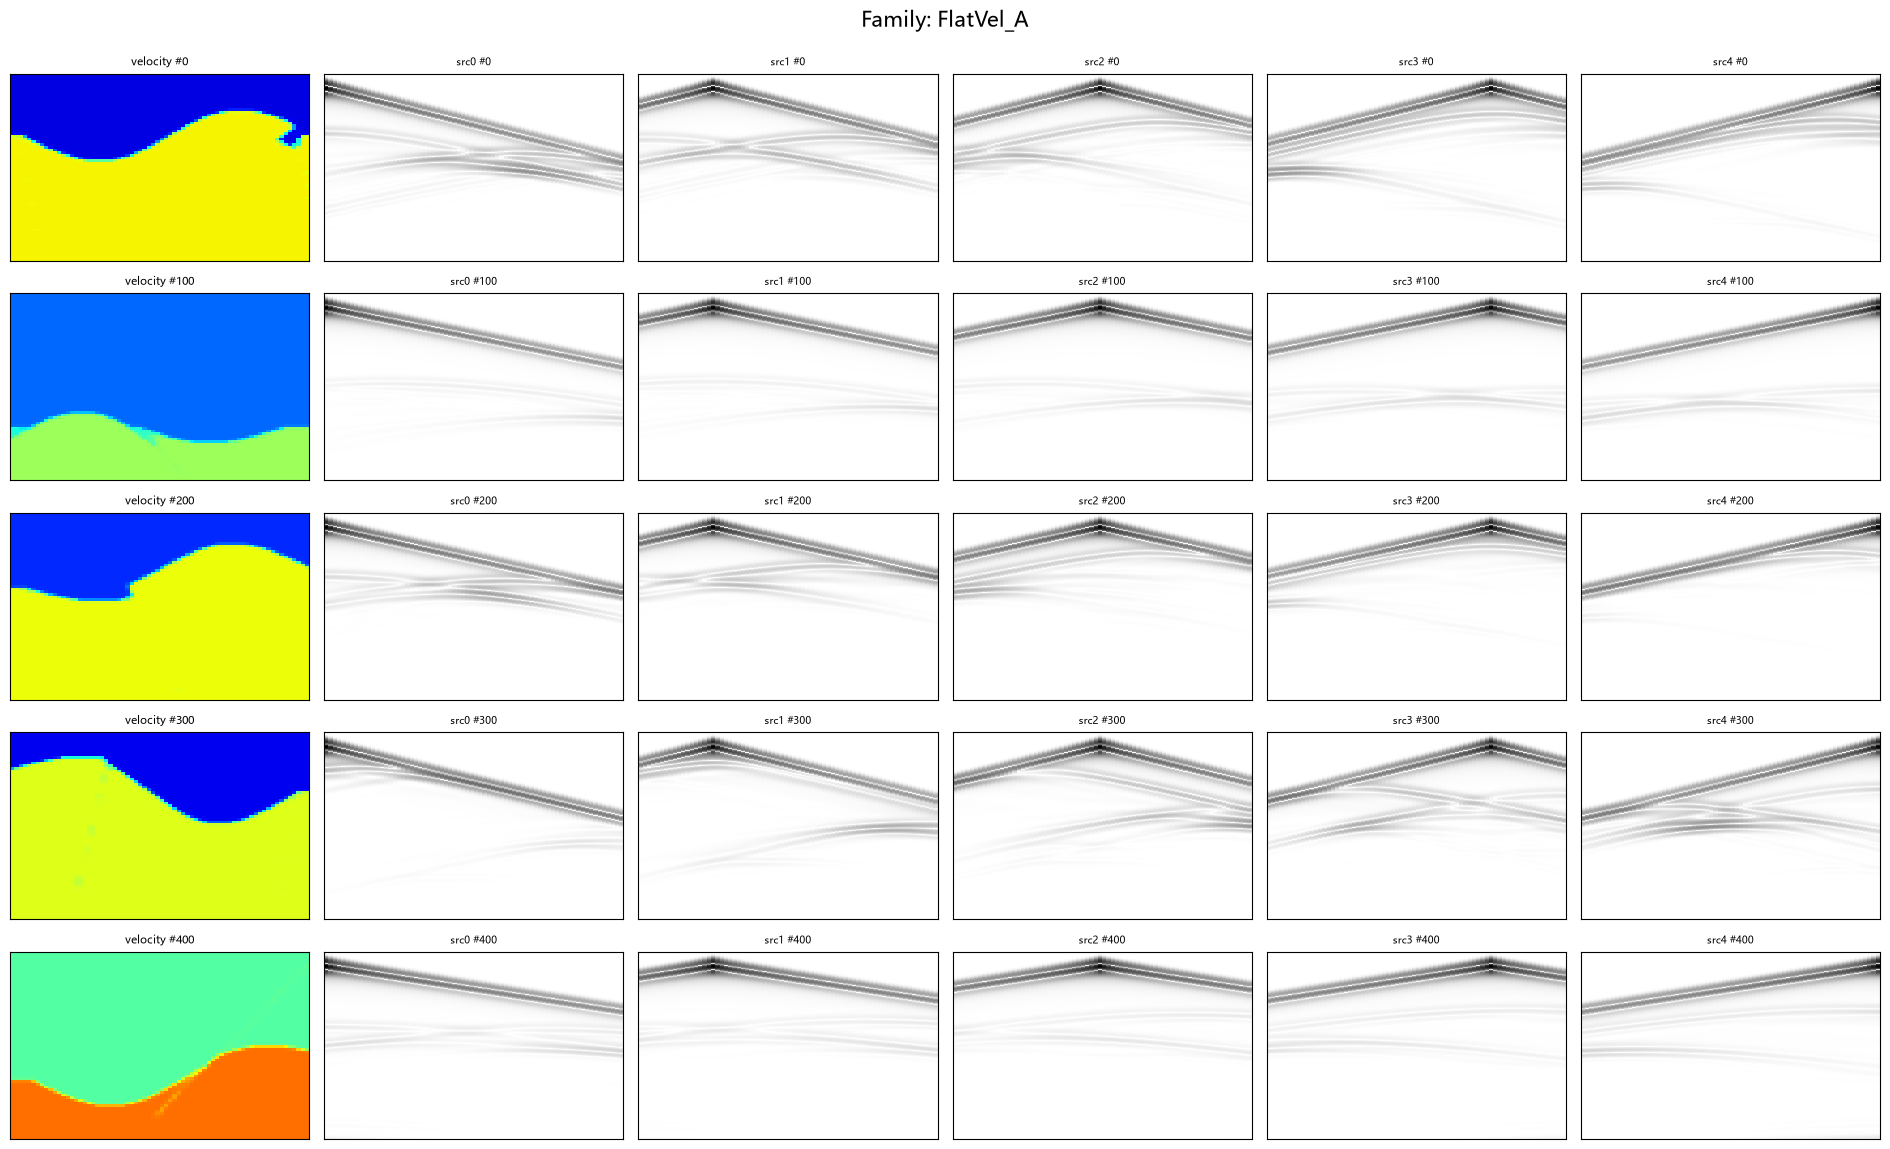

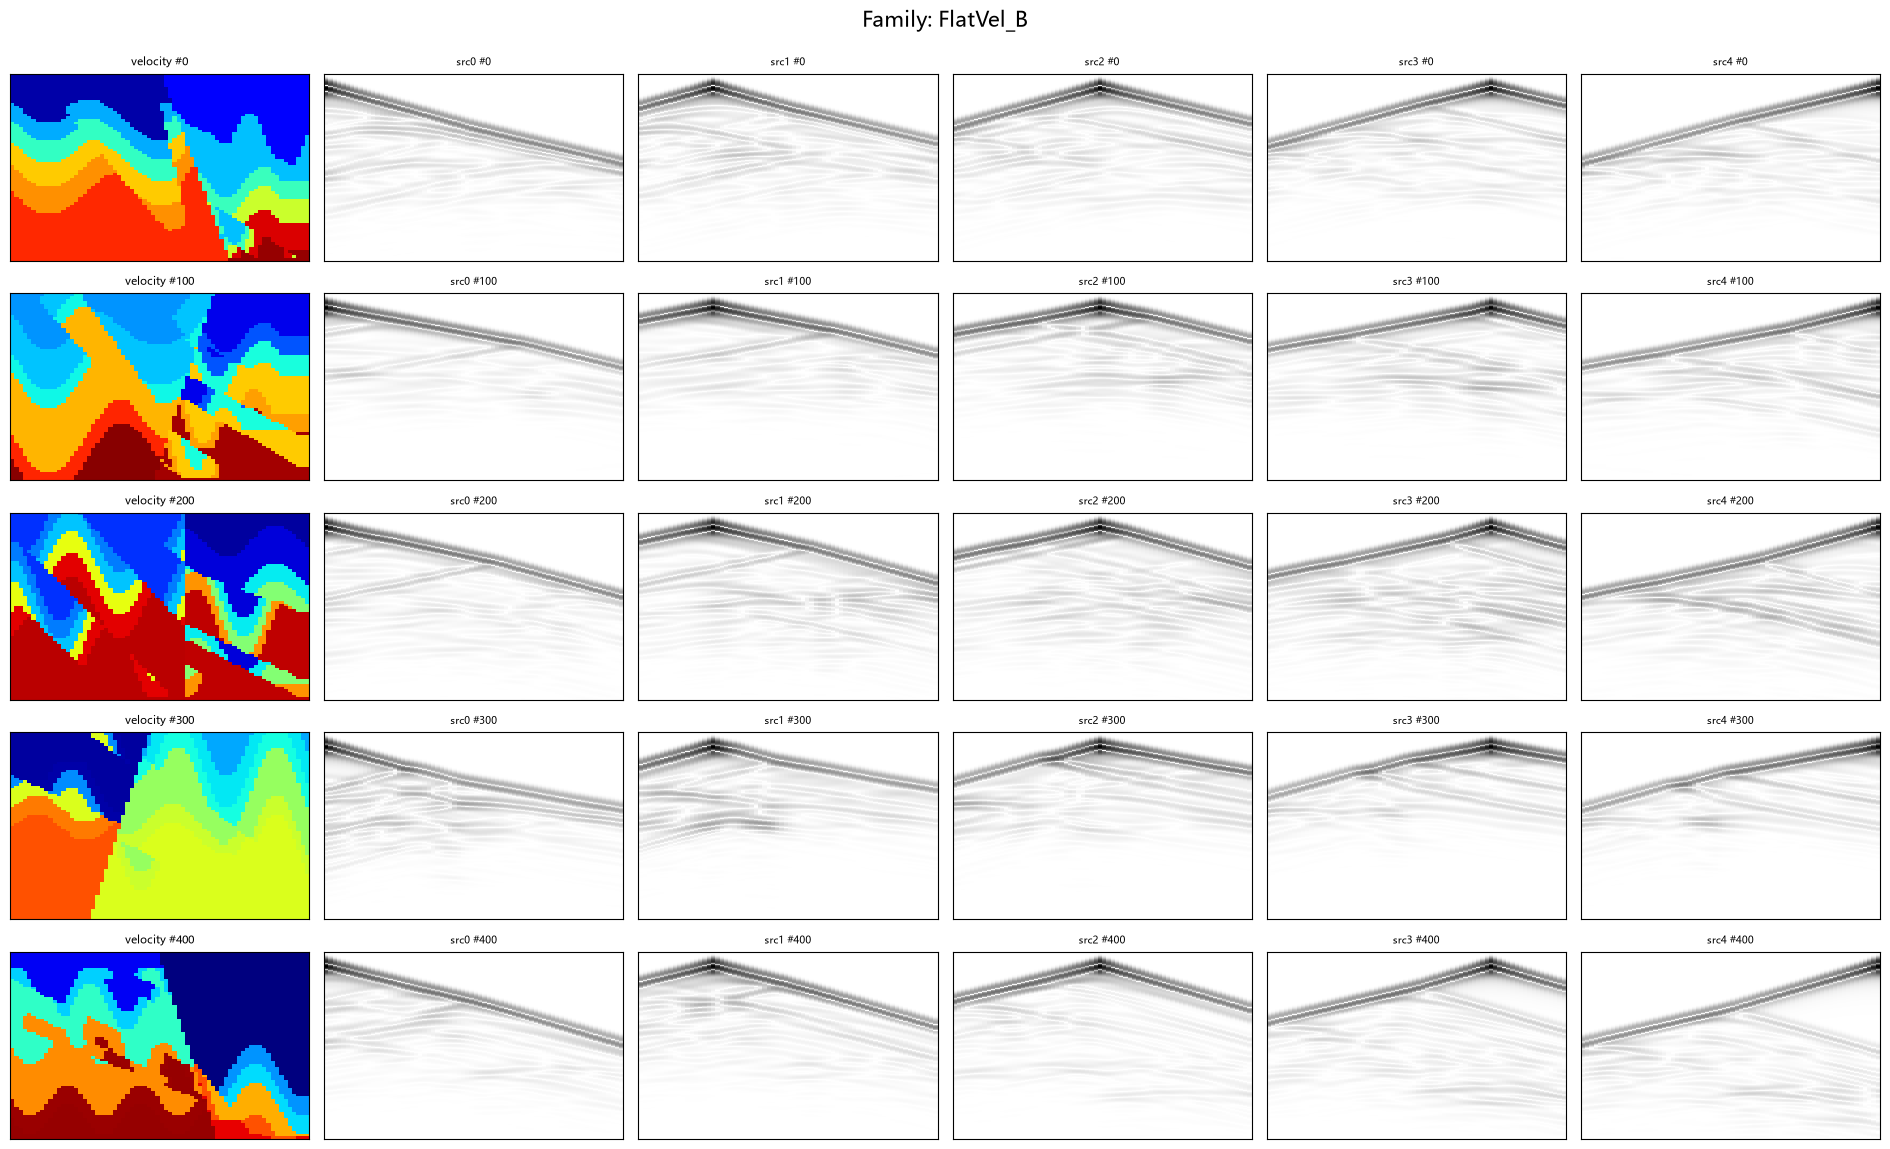

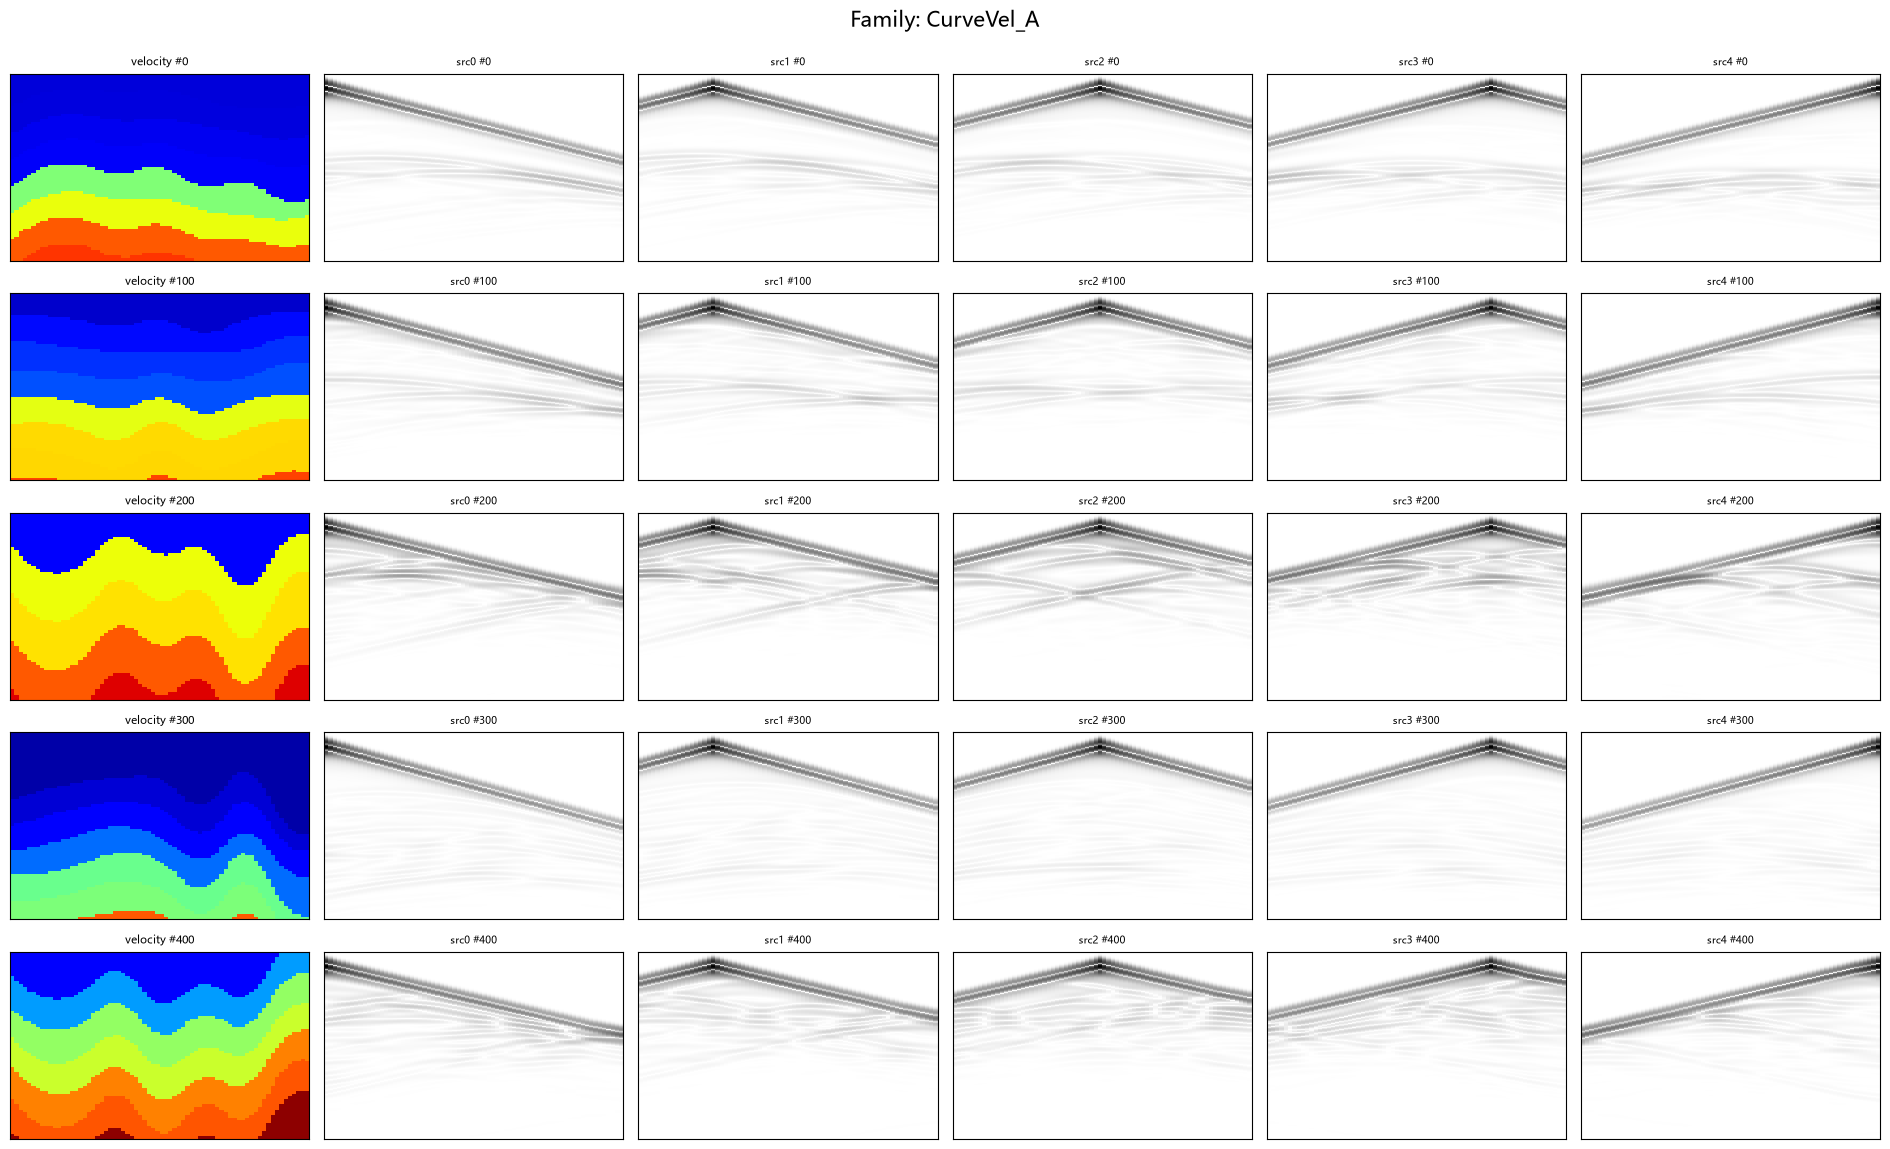

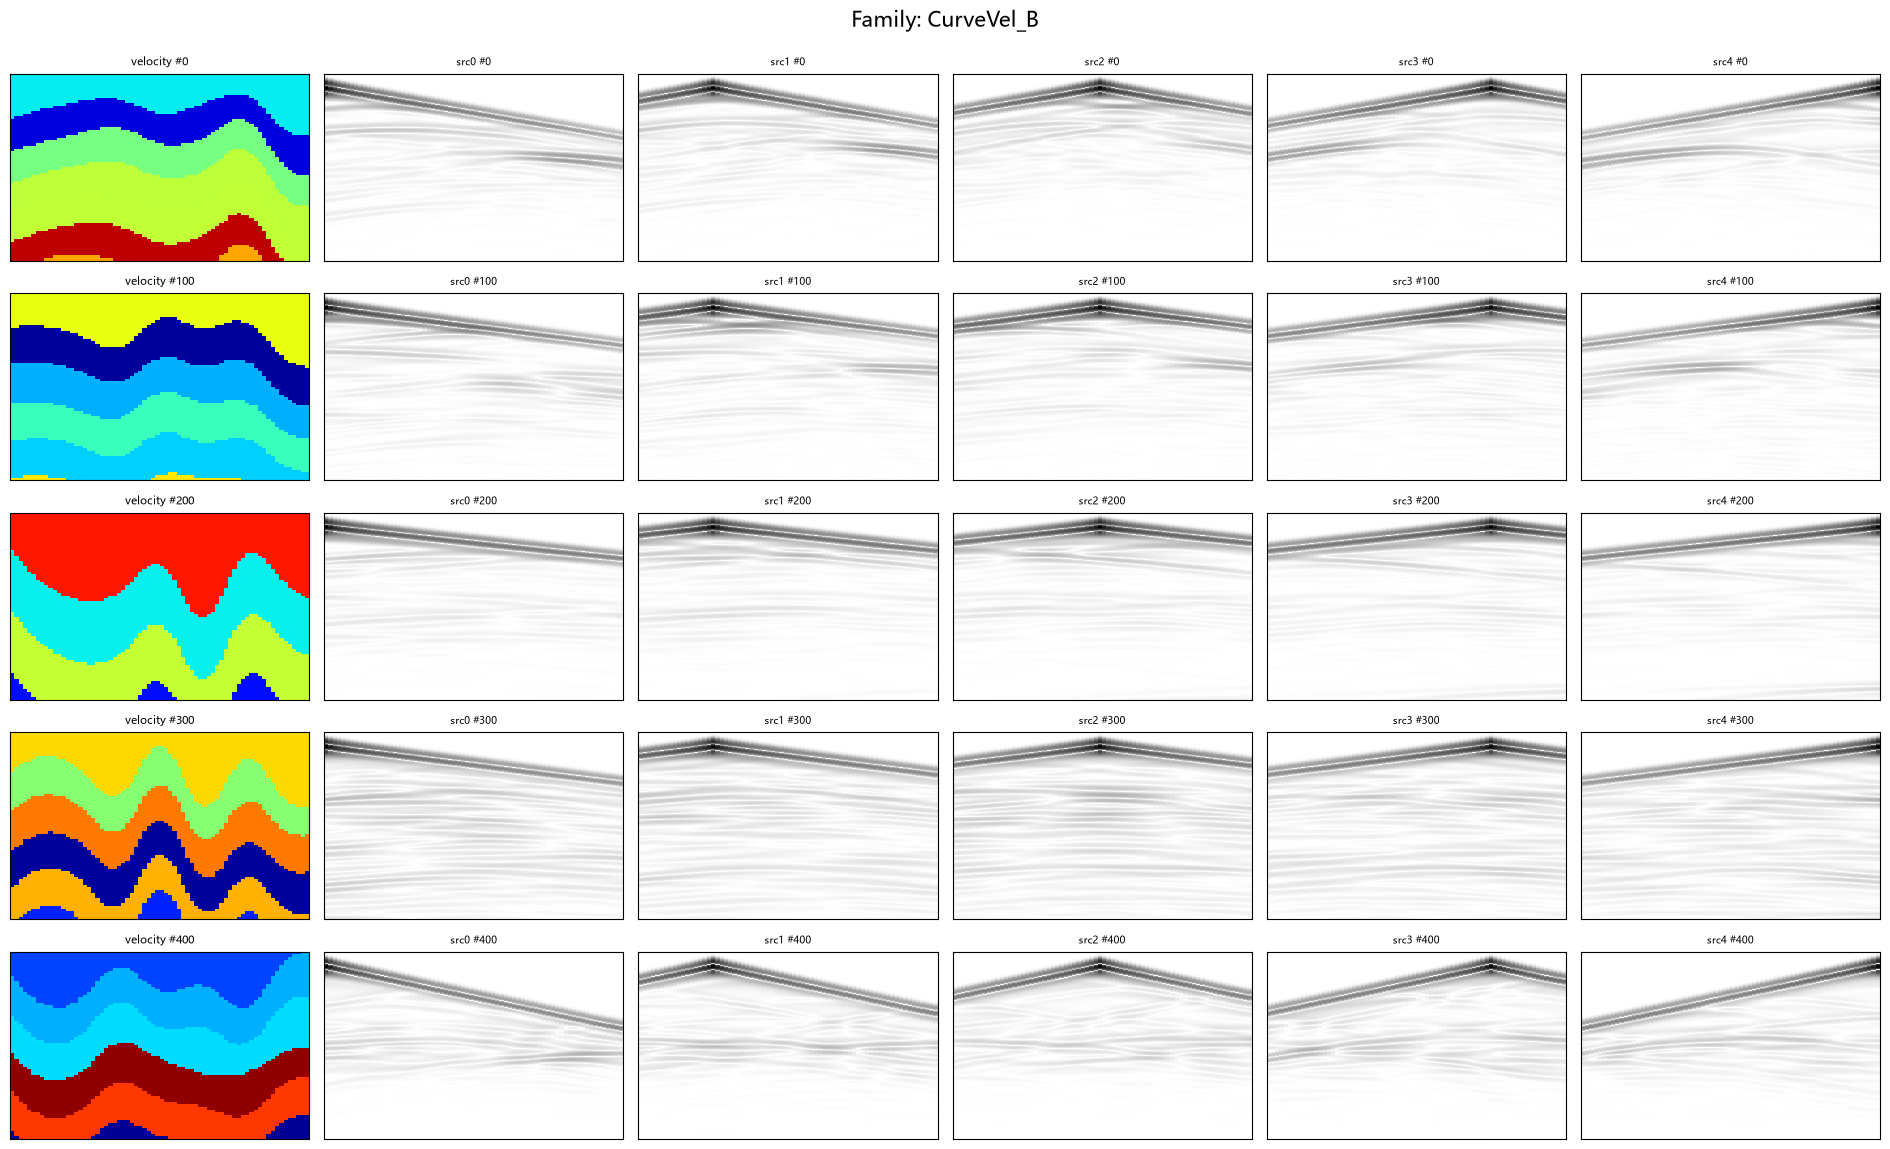

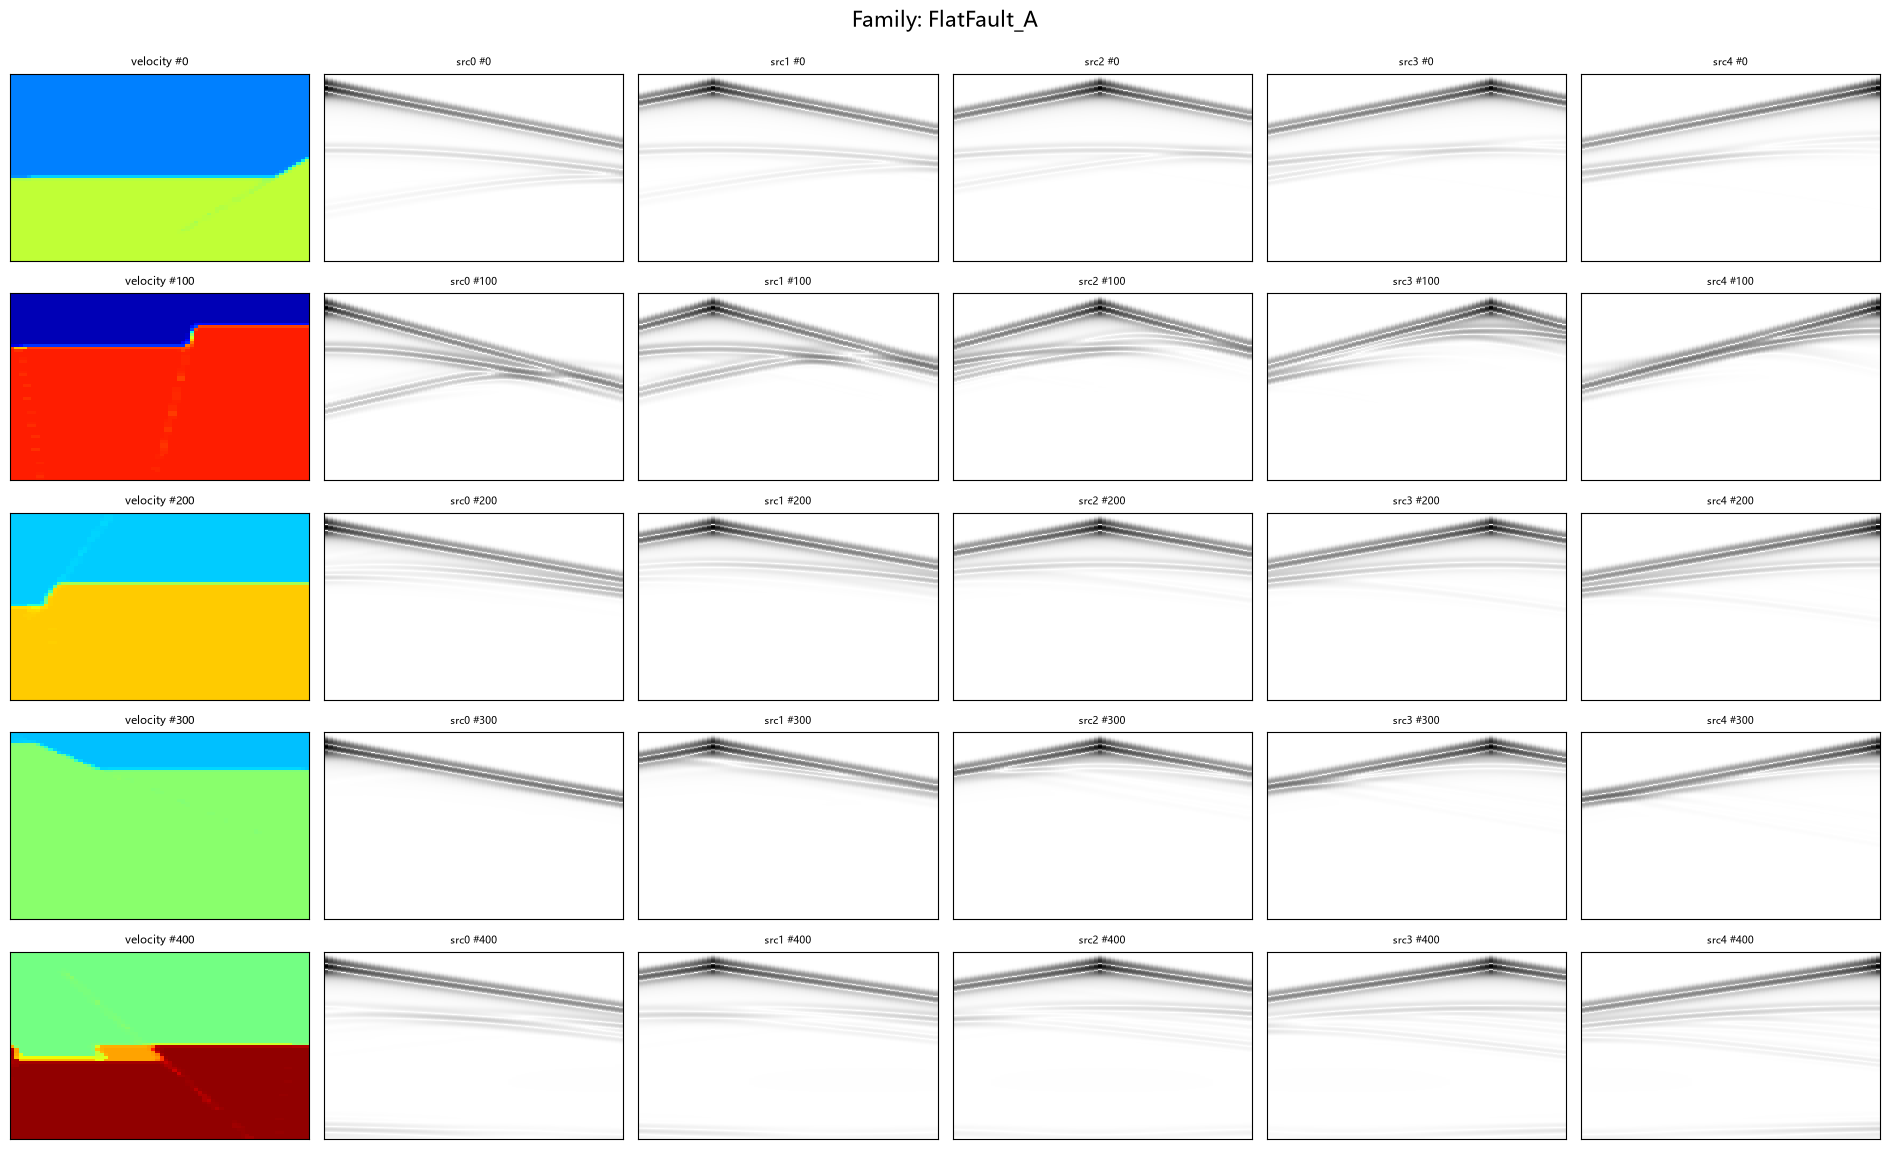

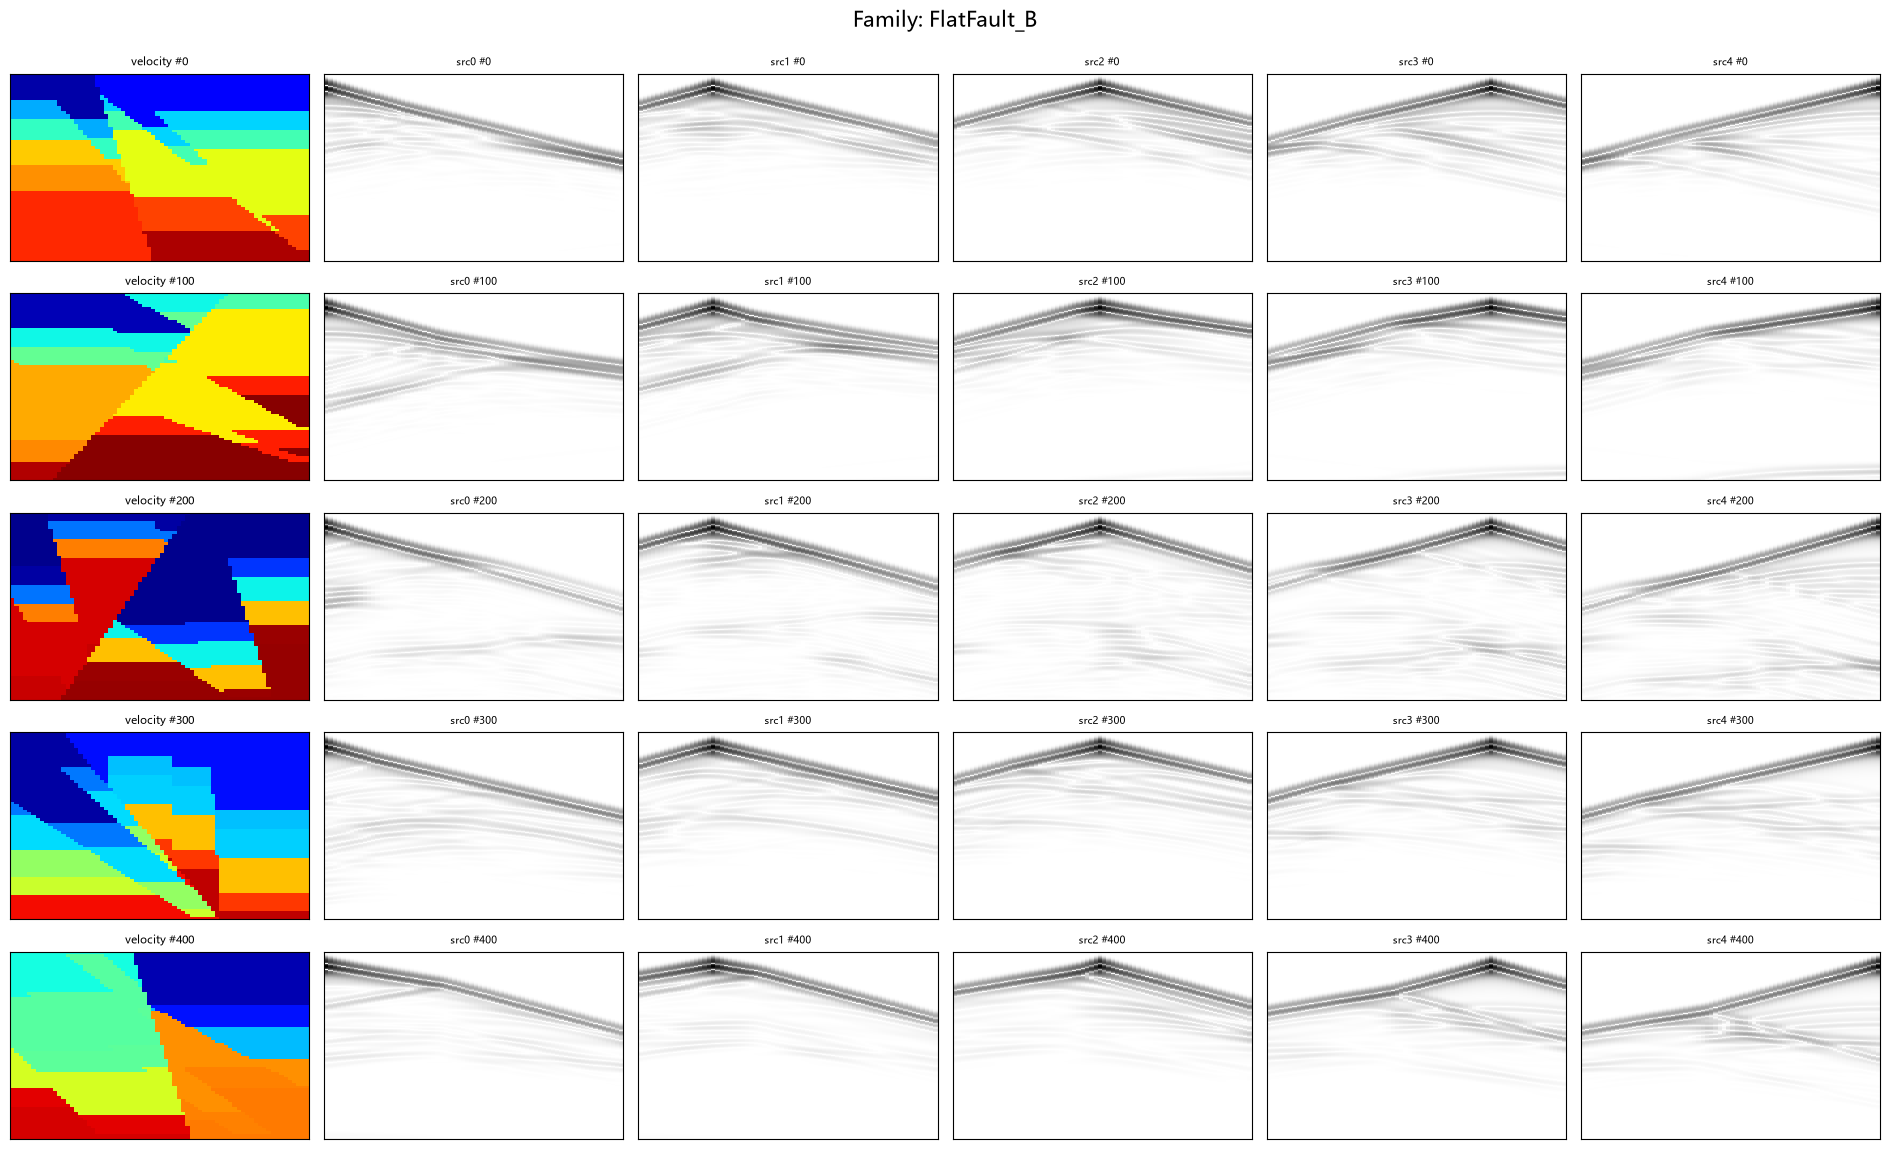

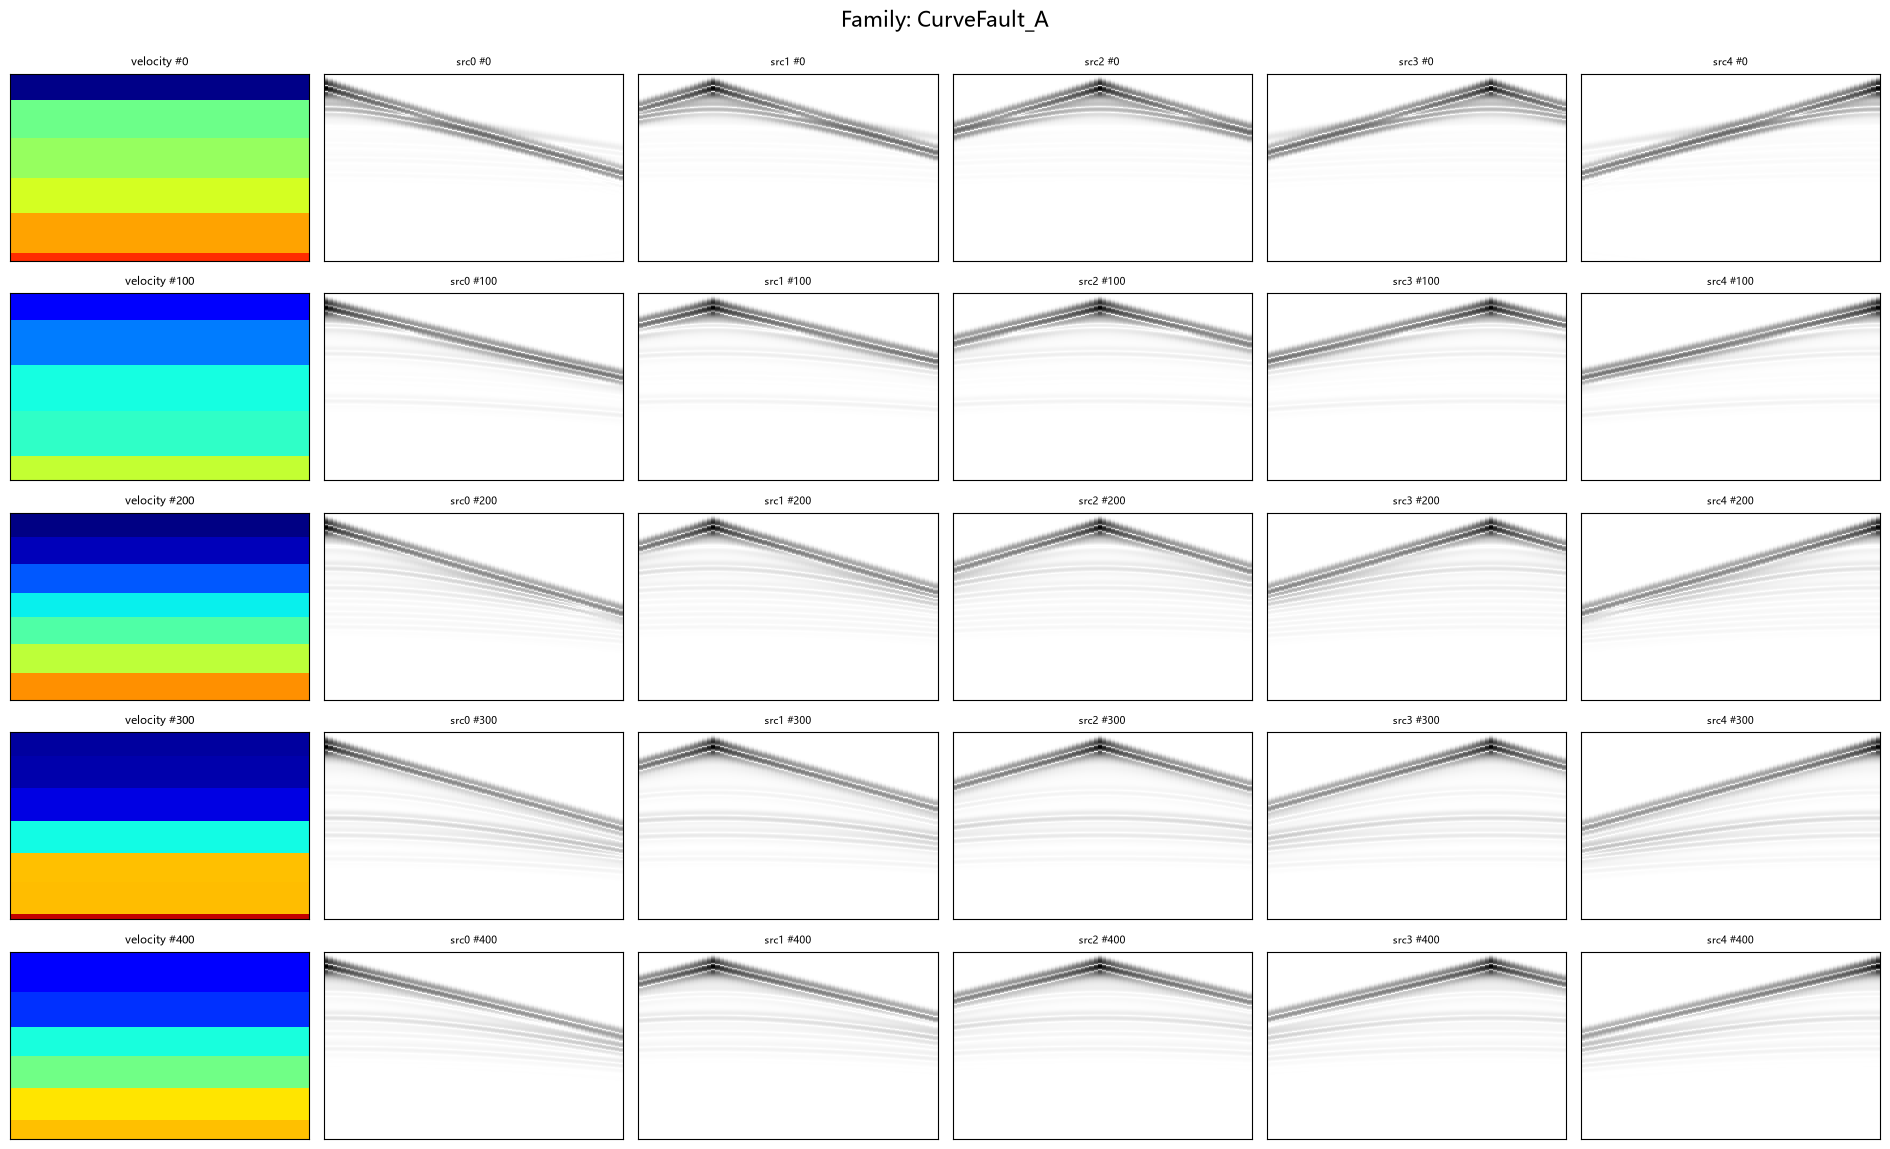

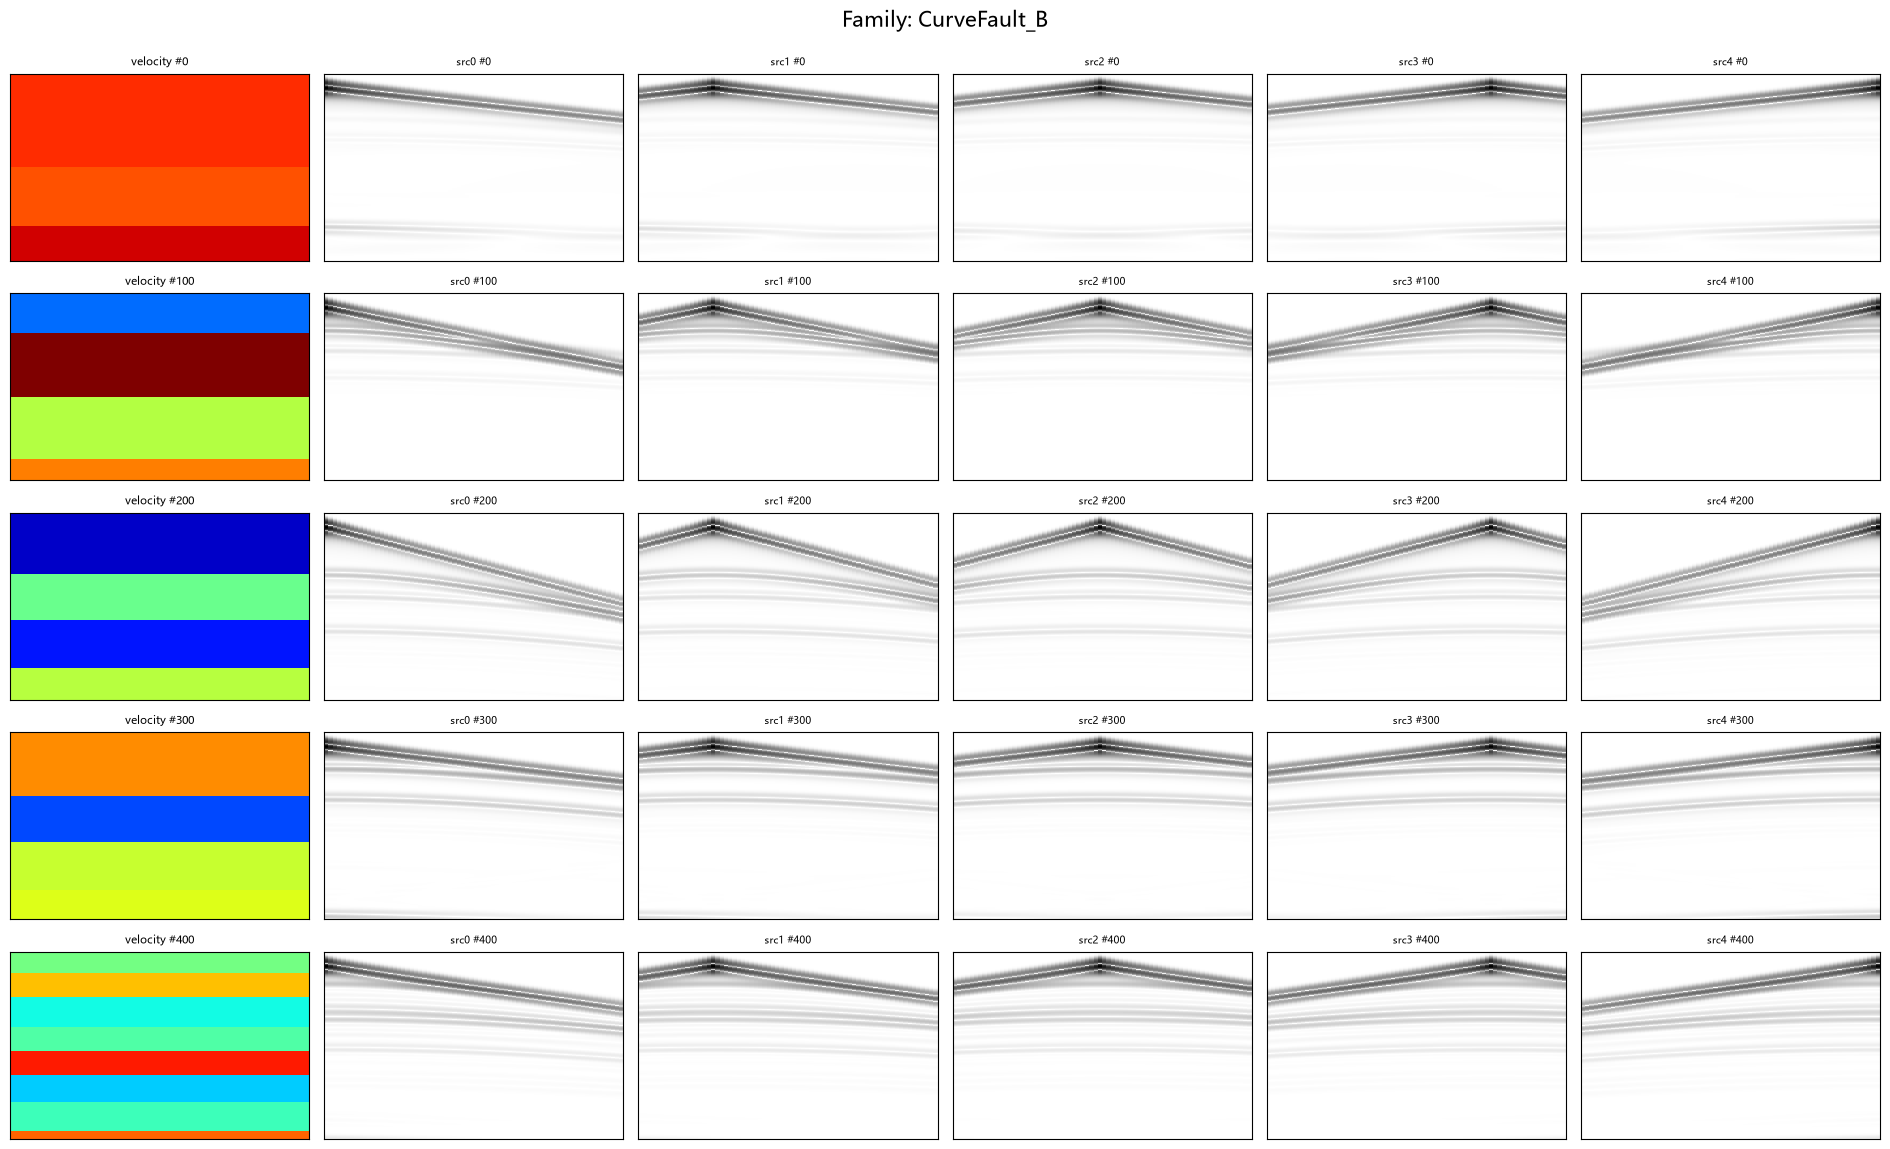

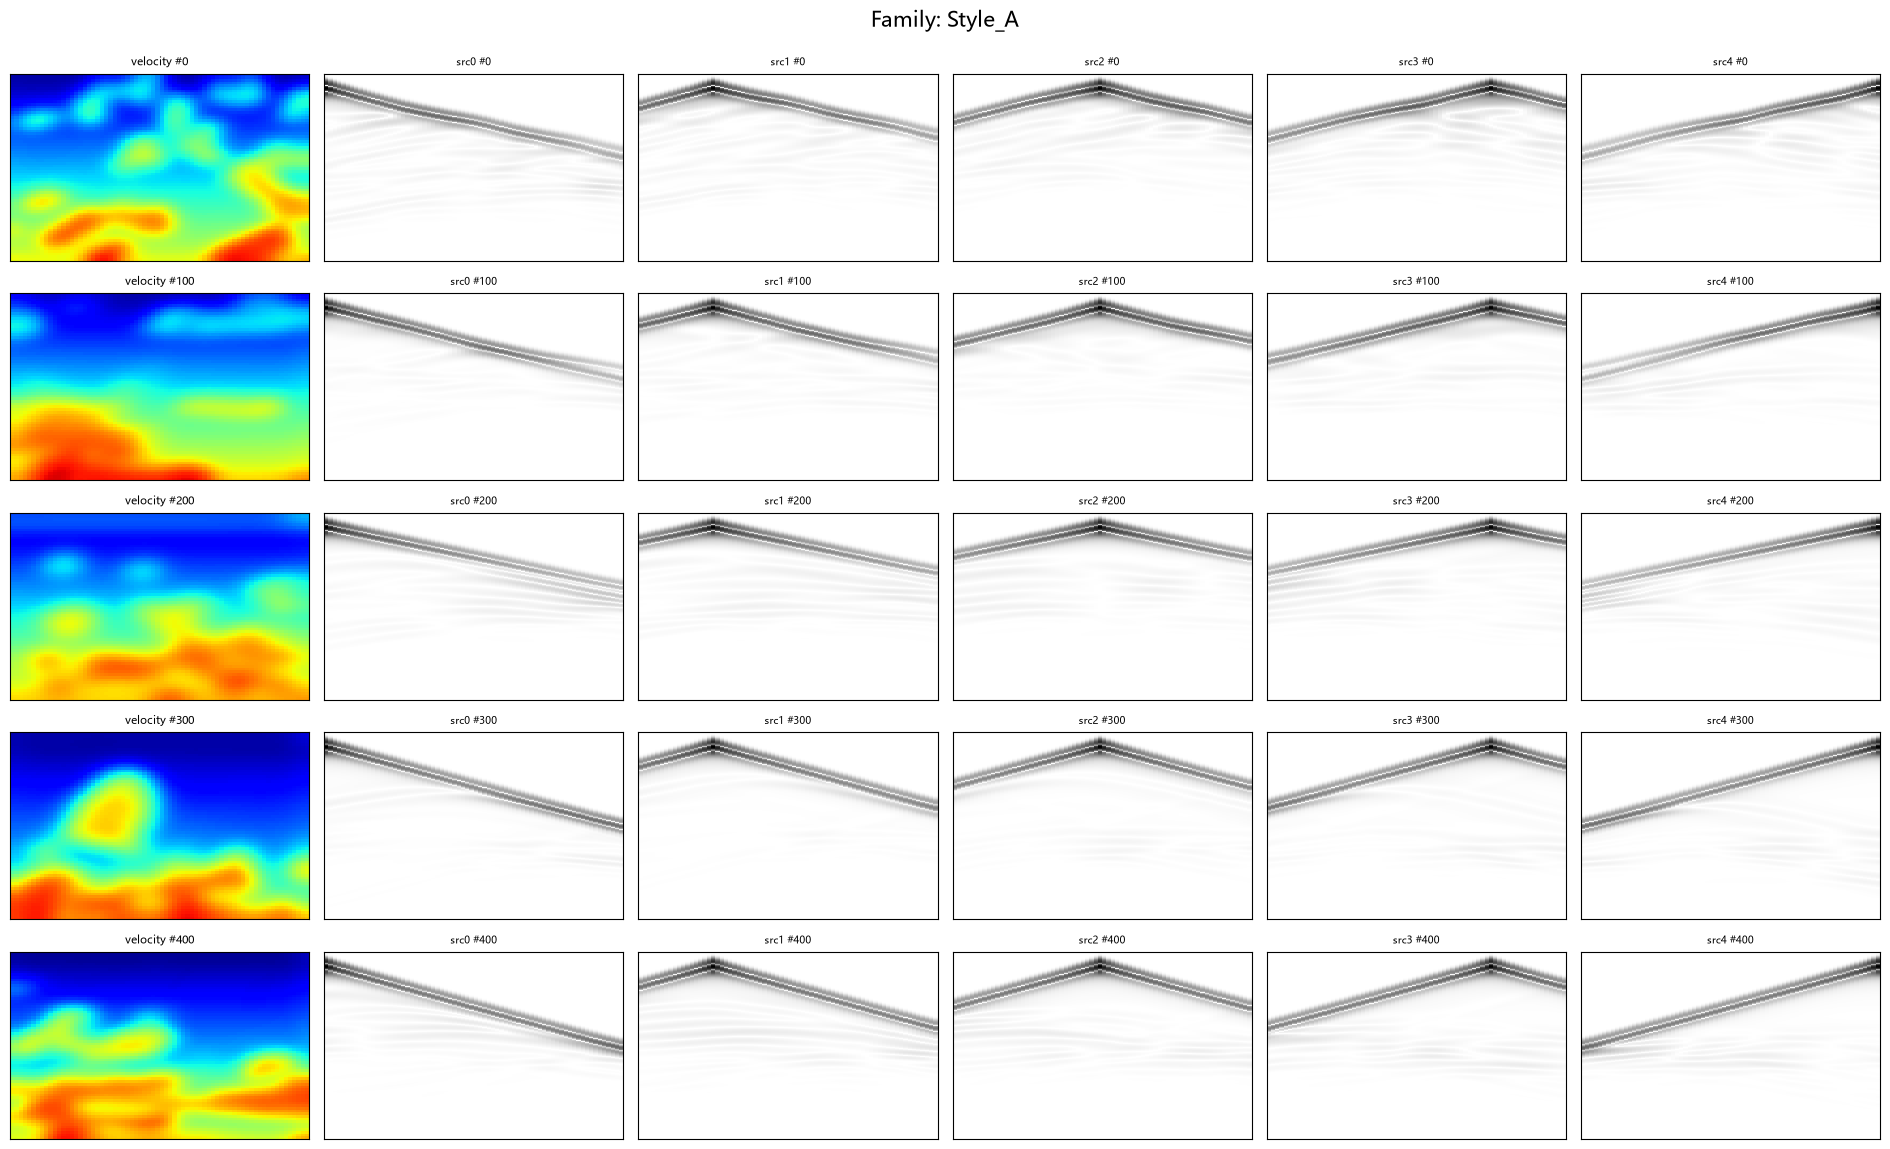

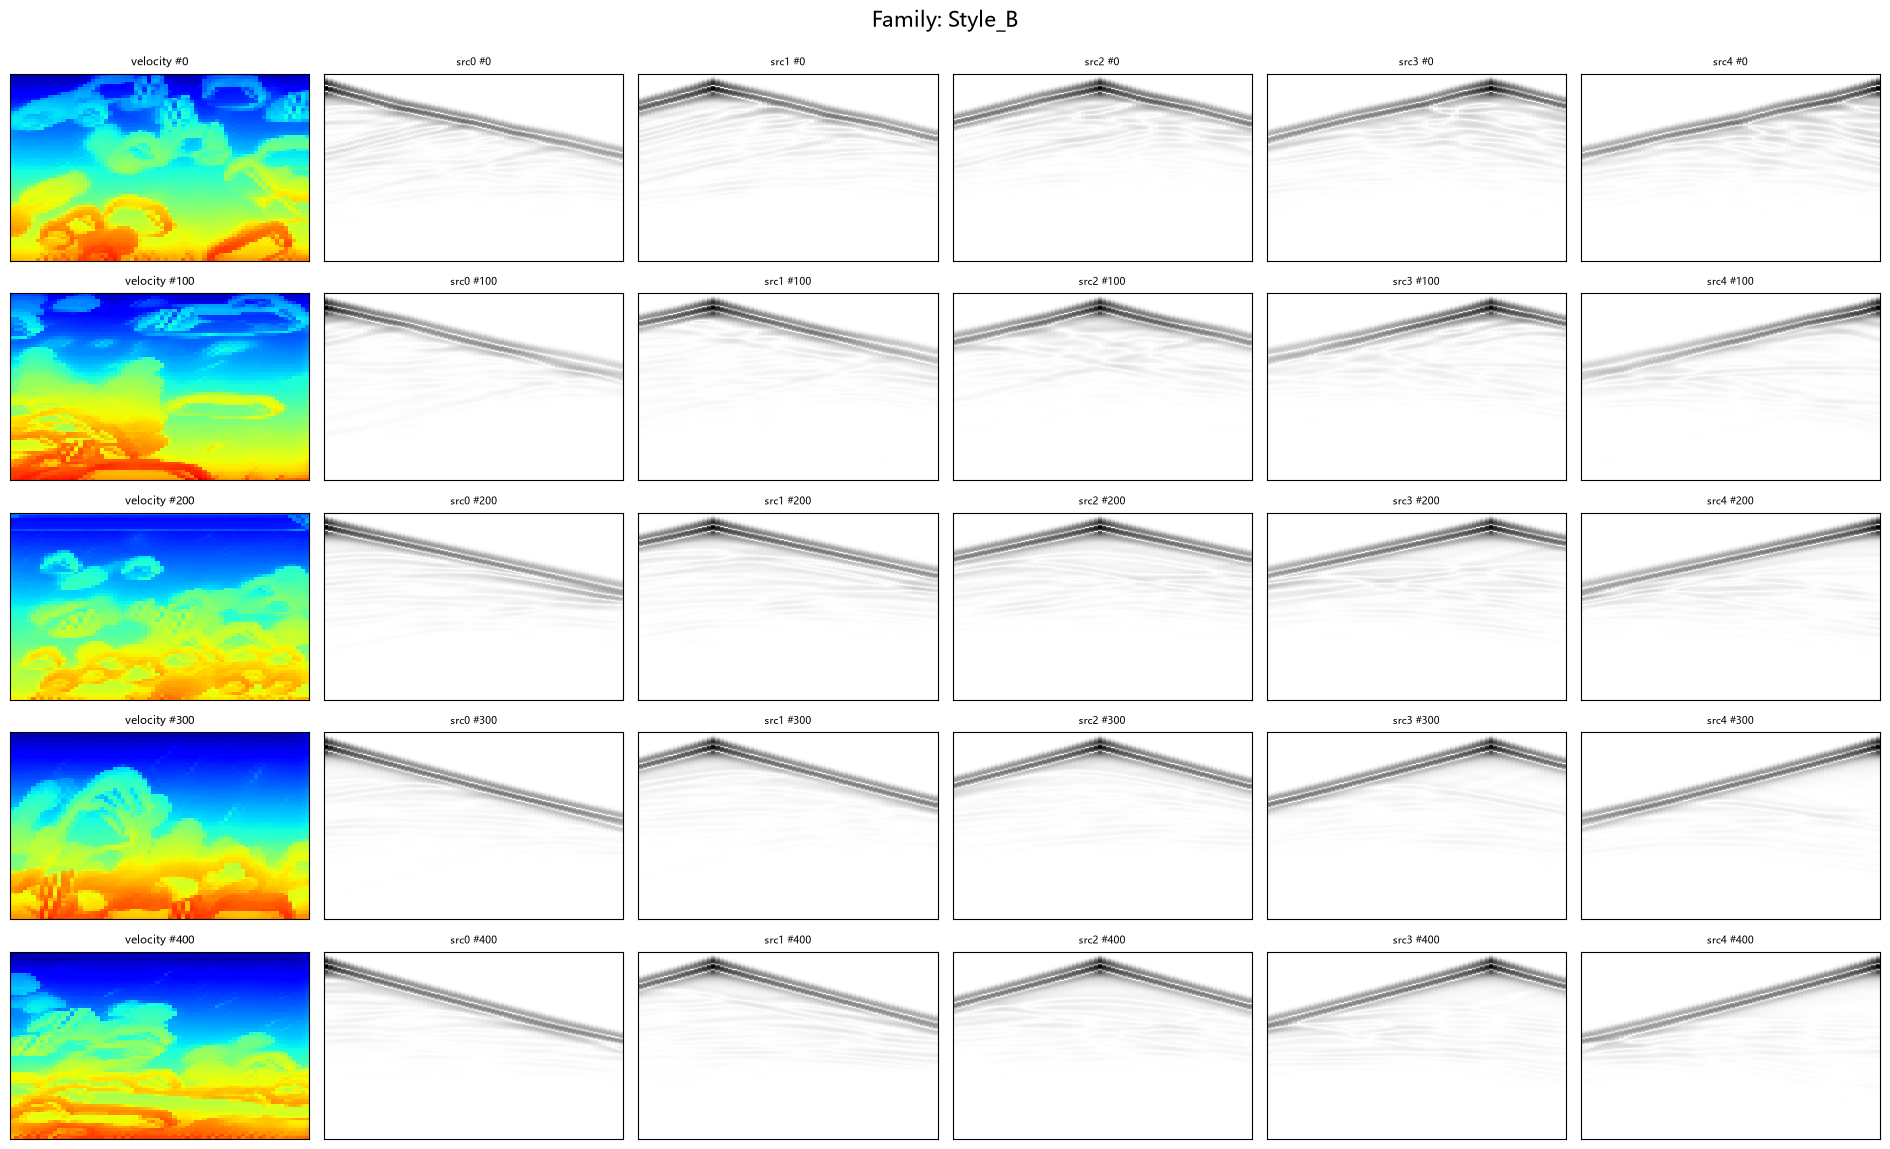

In [2]:
# 2. 每个家族可视化 5 个训练样本（1 速度图 + 5 源地震）
N_PER_FAMILY = 5
sample_ids = [0, 100, 200, 300, 400]   # 每家族取 5 个分布样本

for fi, fam in enumerate(Cfg.families):
    fig, axes = plt.subplots(N_PER_FAMILY, 6, figsize=(19, N_PER_FAMILY * 2.3))
    fig.suptitle(f"Family: {fam}", fontsize=15, y=0.995)
    for r, sid in enumerate(sample_ids):
        seis, vel = load_train_sample(fi, sid)
        # 速度图
        axes[r, 0].imshow(vel, cmap="jet", aspect="auto",
                          interpolation="nearest", vmin=1500, vmax=4500)
        axes[r, 0].set_title(f"velocity #{sid}", fontsize=8)
        axes[r, 0].set_yticks([]); axes[r, 0].set_xticks([])
        # 5 个源
        for s in range(5):
            axes[r, s + 1].imshow(np.log1p(np.abs(seis[s])), cmap="gray_r",
                                  aspect="auto", interpolation="nearest")
            axes[r, s + 1].set_title(f"src{s} #{sid}", fontsize=7)
            axes[r, s + 1].set_yticks([]); axes[r, s + 1].set_xticks([])
    plt.tight_layout()
    plt.show()


前 5 个 test 文件: ['000039dca2.npy', '0000fd8ec8.npy', '0001026c8a.npy', '00015b24d5.npy', '0001e348d0.npy']


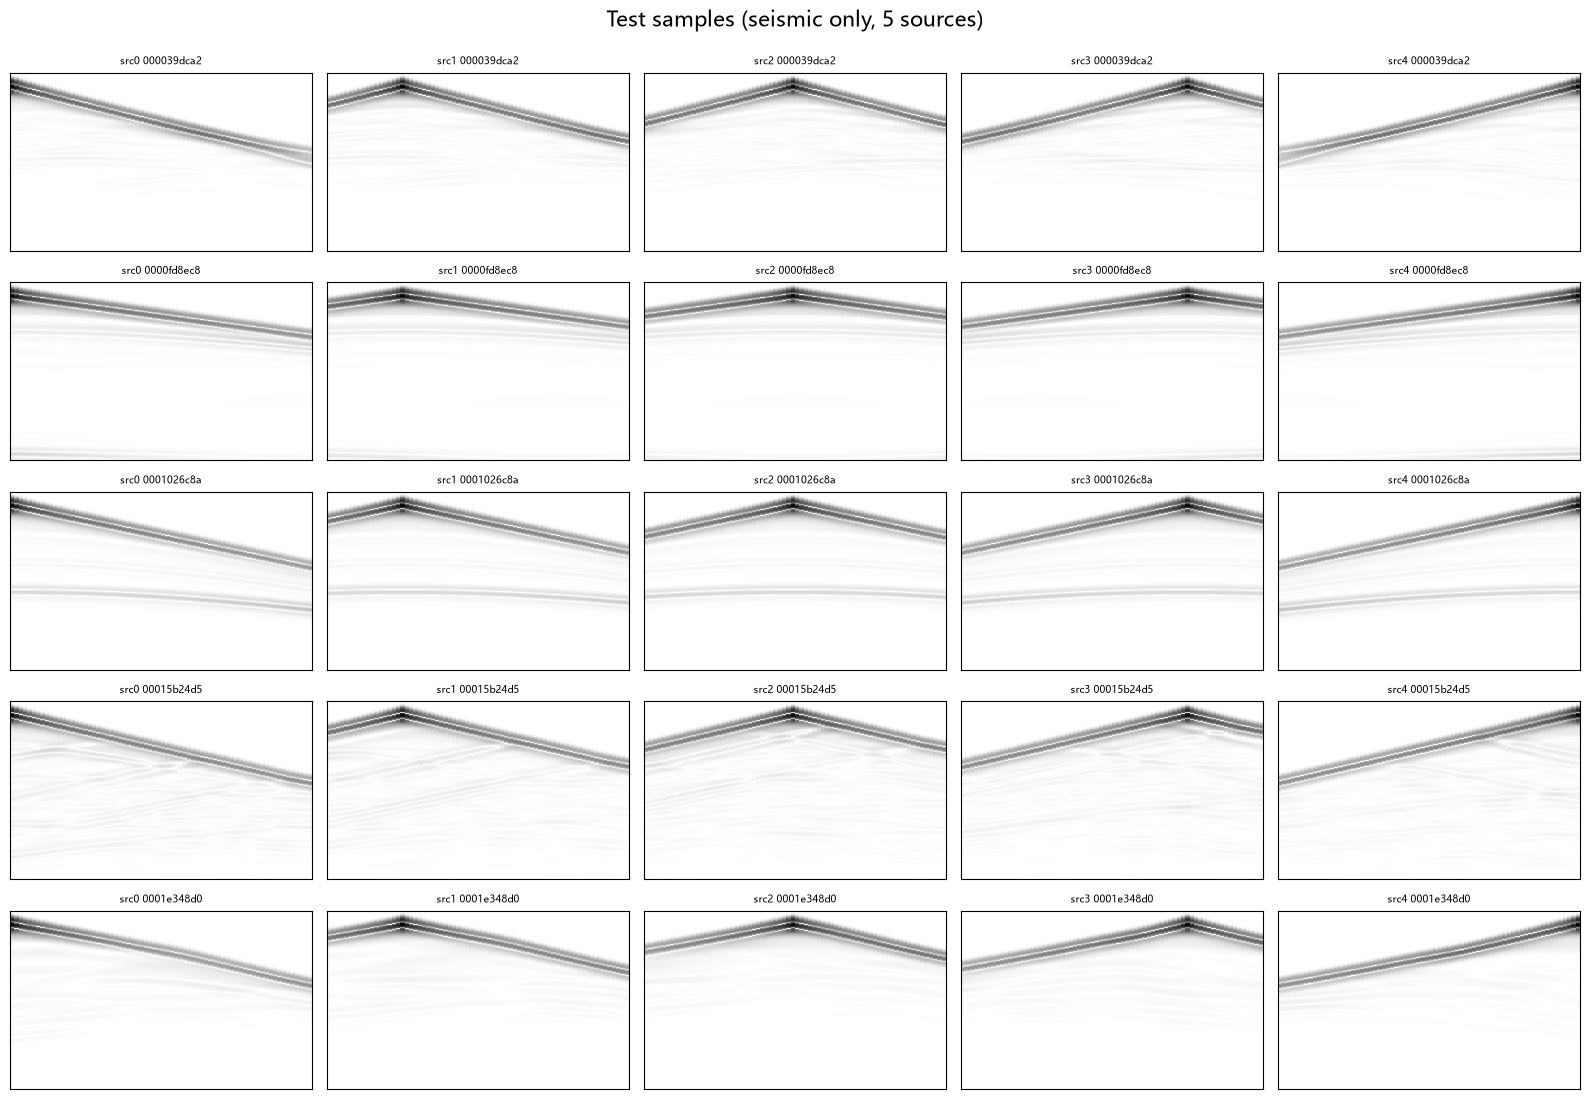

: 

In [ ]:
# 3. 可视化 5 个 test 样本（5 源地震，无速度真值）
test_files = sorted(glob.glob(os.path.join(Cfg.test_data_dir, "*.npy")))[:5]
print("前 5 个 test 文件:", [Path(f).name for f in test_files])

N_TEST = 5
fig, axes = plt.subplots(N_TEST, 5, figsize=(16, N_TEST * 2.2))
fig.suptitle("Test samples (seismic only, 5 sources)", fontsize=15, y=0.995)
for r, fp in enumerate(test_files):
    seis = np.load(fp).astype(np.float32)          # (5,1000,70)
    oid = Path(fp).stem
    for s in range(5):
        axes[r, s].imshow(np.log1p(np.abs(seis[s])), cmap="gray_r",
                          aspect="auto", interpolation="nearest")
        axes[r, s].set_title(f"src{s} {oid[:10]}", fontsize=7)
        axes[r, s].set_yticks([]); axes[r, s].set_xticks([])
plt.tight_layout()
plt.show()
